In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop, Adam


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

2024-12-14 16:26:43.786535: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-14 16:26:45.182858: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-14 16:26:48.309923: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-14 16:26:53.799863: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:




#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/dataset_training_no_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"



In [3]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,5000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [4]:



data = awgn(data, snr_range)

In [5]:
import numpy as np

def apply_random_shift(data, max_shift):
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(data, shift, axis=1)


# Example usage
max_shift = 7


# Apply random shift and noise to a single sample
augmented_sample = apply_random_shift(data, max_shift)



In [6]:
data=augmented_sample

In [7]:
data.shape

(5000, 8192)

Generated CAZAC Preamble:
[ 1.        +0.00000000e+00j  0.87822157-4.78253979e-01j
  0.07473009-9.97203797e-01j -0.98883083-1.49042266e-01j
  0.27084047+9.62624247e-01j  0.36534102-9.30873749e-01j
 -0.5       +8.66025404e-01j  0.17364818-9.84807753e-01j
  0.6234898 +7.81831482e-01j -0.90096887+4.33883739e-01j
 -0.66168584-7.49781203e-01j  0.07473009-9.97203797e-01j
  0.36534102-9.30873749e-01j  0.17364818-9.84807753e-01j
 -0.5       -8.66025404e-01j -0.98883083+1.49042266e-01j
  0.27084047+9.62624247e-01j  0.6234898 -7.81831482e-01j
 -0.90096887+4.33883739e-01j  0.87822157-4.78253979e-01j
 -0.5       +8.66025404e-01j -0.5       -8.66025404e-01j
  0.87822157-4.78253979e-01j  0.82623877+5.63320058e-01j
  0.36534102+9.30873749e-01j  0.27084047+9.62624247e-01j
  0.6234898 +7.81831482e-01j  1.        +2.15587355e-14j
  0.17364818-9.84807753e-01j]


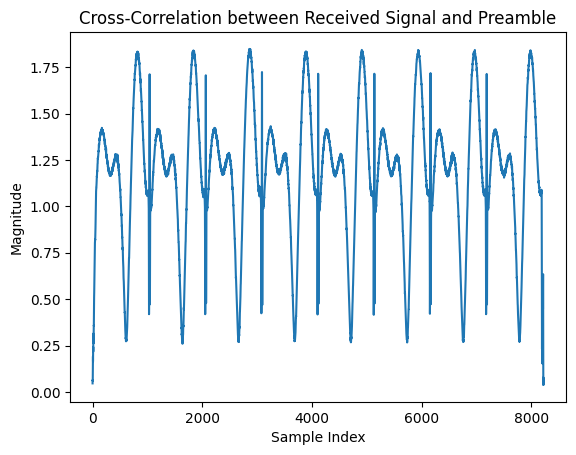

Detected preamble start at index: 2859
Entire detected preamble:
[ 0.09519575+0.19606038j  0.04599757+0.21101269j -0.0053056 +0.21879567j
 -0.05270912+0.21175276j -0.10036424+0.19271552j -0.14204363+0.16385186j
 -0.17725371+0.12664957j -0.20135193+0.08317367j -0.21428576+0.03429235j
 -0.21599723-0.01843075j -0.20698403-0.06921217j -0.18403753-0.11545942j
 -0.15170244-0.15613822j -0.11124598-0.18793711j -0.06350869-0.20854525j
 -0.01051273-0.21697547j  0.04163931-0.21285579j  0.09135738-0.19784057j
  0.13539143-0.17007074j  0.17210671-0.13161455j  0.20036455-0.0873216j
  0.21523021-0.03711011j  0.21565427+0.01801664j  0.20521119+0.07187338j
  0.18156949+0.1199821j   0.14637686+0.16106337j  0.10087543+0.19252367j
  0.04983472+0.21178674j -0.00269681+0.21783172j]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Generate CAZAC (Zadoff-Chu) sequence
def generate_cazac(N, root):
    n = np.arange(29)  # Using 29 elements as per your setup
    cazac_seq = np.exp(-1j * np.pi * root * n * (n + 1) / N)
    
    # Print the generated preamble (CAZAC sequence)
    print("Generated CAZAC Preamble:")
    print(cazac_seq)
    
    return cazac_seq

# Cross-correlation function
def cross_correlation(received_signal, preamble):
    # Compute the cross-correlation between received signal and preamble
    preamble_conjugate = np.conj(preamble)  # Use the conjugate of the preamble
    correlation = np.correlate(received_signal, preamble_conjugate, mode='full')
    return correlation

# Your noisy RF dataset (replace 'data' with your actual dataset)
received_signal = data[0]  # Assuming data is a 2D array and you're using the first row

# Length of the CAZAC sequence
N = 63
root = 5  # Root of the Zadoff-Chu sequence

# Generate the CAZAC preamble sequence
cazac_preamble = generate_cazac(N, root)

# Perform cross-correlation between the received signal and preamble
correlation = cross_correlation(received_signal, cazac_preamble)

# Plot the correlation to detect the peak
plt.plot(np.abs(correlation))
plt.title('Cross-Correlation between Received Signal and Preamble')
plt.xlabel('Sample Index')
plt.ylabel('Magnitude')
plt.show()

# Detect the peak position
peak_index = np.argmax(np.abs(correlation))
print(f"Detected preamble start at index: {peak_index}")

# Length of the preamble (same as the length of the CAZAC sequence)
preamble_length = len(cazac_preamble)

# Extract the detected preamble starting from peak_index
detected_preamble = received_signal[peak_index:peak_index + preamble_length]


# If you want to print the entire detected preamble
print("Entire detected preamble:")
print(detected_preamble)




In [8]:
preamble=detected_preamble
data_input=data

In [13]:
preamble

array([ 0.10611268,  0.09948081,  0.09275429,  0.08596456,  0.07907059,
        0.07215927,  0.06527611,  0.05848444,  0.05188464,  0.04519258,
        0.03849694,  0.03194584,  0.02564898,  0.01937716,  0.01311069,
        0.00685749,  0.00085813, -0.00504144, -0.01070186, -0.01633544,
       -0.02159419, -0.02673319, -0.03159221, -0.03622005, -0.04065218,
       -0.04522778, -0.04933592, -0.0533032 , -0.05701709])

In [9]:
import numpy as np

# Assuming data_input is your input dataset and preamble is your synchronization preamble.

# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    # Compute the cross-correlation between the conjugate of the preamble and the current data row
    corr = np.correlate(data_input[i], np.conjugate(preamble), mode='full')
    
    # Find the peak index in the correlation result
    peak_index = np.argmax(corr)
    
    # Calculate synchronization offset
    sync_offset = peak_index - (len(preamble) - 1)  # Adjust to center the peak
    
    # Ensure the offset is valid
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = int(np.round(np.mean(sync_offsets)))  # Use the average to reduce outliers

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    
    for i in range(data_input.shape[0]):
        # Only synchronize if the offset is within the valid range
        if most_common_offset < data_input.shape[1]:  
            synchronized_data[i] = data_input[i, most_common_offset:]  # Keep data starting from the offset
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Handle edge case
    
    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...
    print("Synchronized data shape:", synchronized_data.shape)


Most Common Synchronization Offset: 3920
Synchronized data shape: (5000, 4272)


/tmp/ipykernel_2182/2965744305.py:34: ComplexWarning: Casting complex values to real discards the imaginary part
  synchronized_data[i] = data_input[i, most_common_offset:]  # Keep data starting from the offset


/home/codespace/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/codespace/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


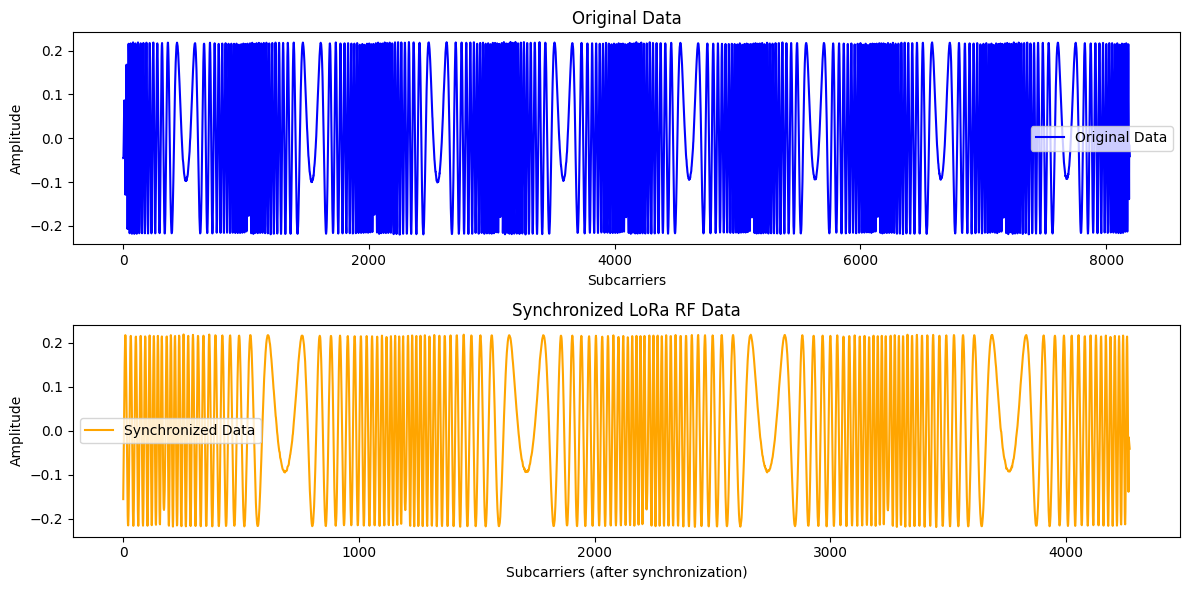

In [10]:
import matplotlib.pyplot as plt

# Plot original data and synchronized data for the first symbol
plt.figure(figsize=(12, 6))

# Original Data
plt.subplot(2, 1, 1)
plt.plot(data_input[0], label='Original Data', color='blue')
plt.title('Original Data')
plt.xlabel('Subcarriers')
plt.ylabel('Amplitude')
plt.legend()

# Synchronized Data
plt.subplot(2, 1, 2)
plt.plot(synchronized_data[0], label='Synchronized Data', color='orange')
plt.title('Synchronized LoRa RF Data')
plt.xlabel('Subcarriers (after synchronization)')
plt.ylabel('Amplitude')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
synchronized_data.shape

(5000, 4765)

In [11]:
data=synchronized_data

In [12]:
preamble=data[:512, :2]


In [13]:
import numpy as np

def coarse_cfo_estimation(preamble, symbol_length, B, Ts):
    """
    Perform coarse CFO compensation based on the provided preamble and parameters.

    Parameters:
    preamble (np.ndarray): Received baseband signal r[n], a 2D array representing the preamble.
    symbol_length (int): Length of the preamble.
    B (float): Bandwidth of the system.
    Ts (float): Sampling time period.

    Returns:
    compensated_signal (np.ndarray): Coarse CFO compensated signal r'[n].
    """

    # Step 1: Compute instantaneous frequency for each time index
    n = np.arange(symbol_length)
    f_n = -B/2 + (B/T)*Ts*n

    # Step 2: Estimate the coarse CFO (equation 10 from the image)

    delta_f_coarse = 1/symbol_length * np.sum(f_n)  # Estimated CFO
    avg_coarse = np.mean(delta_f_coarse)

    return avg_coarse


# Assuming you have the preamble as a numpy array and other parameters
#preamble = np.array([
      
   #    ])

preamble=preamble

symbol_length = 512
B = 125e3  # Example bandwidth for LoRa
Ts = 1 / 125e3  # Sampling period for LoRa devices
T=0.004096

avg_coarse= coarse_cfo_estimation(preamble, symbol_length, B, Ts)

r=data.shape[0]
# Step 3: Perform coarse frequency compensation (equation 12 from the image)
compensated_signal = data * np.exp(-2j * np.pi * avg_coarse * Ts *r )
print("Compensated Signal:")
print(compensated_signal)

# Resample the preamble and compensated signals for plotting
#resample_factor = 5  # Adjust this value as needed
#preamble_resampled = preamble[::resample_factor]
#compensated_signal_resampled = compensated_signal[::resample_factor]





("Estimated Coarse Frequency Offset (Delta f_coarse):", avg_coarse)


Compensated Signal:
[[-0.11531706+0.10451729j -0.08324492+0.0754488j  -0.0471963 +0.04277623j
  ... -0.02117689+0.01919362j -0.02592588+0.02349785j
  -0.03039218+0.02754586j]
 [ 0.02492256-0.02258849j  0.05941193-0.05384784j  0.09654219-0.08750074j
  ... -0.00302312+0.00273999j -0.00904076+0.00819407j
  -0.01660554+0.01505038j]
 [ 0.15020023-0.13613355j  0.15400353-0.13958066j  0.14417693-0.13067436j
  ...  0.01987154-0.01801051j  0.02175717-0.01971955j
   0.01507974-0.01366748j]
 ...
 [ 0.28943806-0.26233136j  0.34570051-0.31332468j  0.38024   -0.34462944j
  ...  0.03772322-0.03419033j  0.027737  -0.02513936j
   0.01168243-0.01058834j]
 [ 0.00141031-0.00127823j  0.09938934-0.09008124j  0.19208519-0.17409587j
  ... -0.01939746+0.01758083j -0.03562439+0.03228807j
  -0.0566545 +0.05134865j]
 [ 0.1764613 -0.1599352j   0.08328811-0.07548794j -0.01478621+0.01340144j
  ...  0.05051771-0.04578658j  0.06764325-0.06130827j
   0.08194661-0.07427208j]]


('Estimated Coarse Frequency Offset (Delta f_coarse):', -122.0703125)

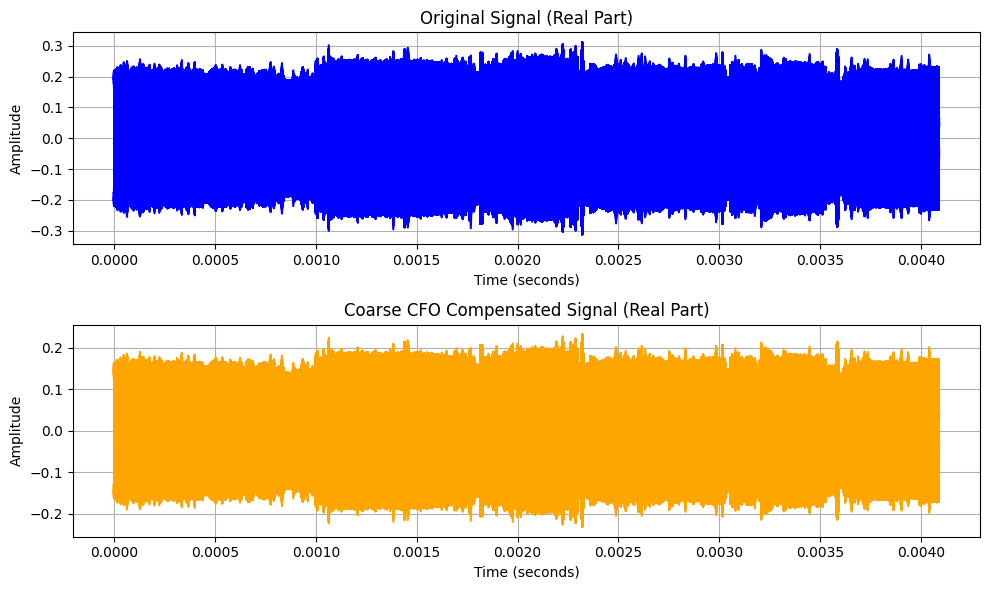

In [14]:


# Step 3: Plot the real (original) data and compensated data
# Extract real parts for visualization purposes
real_original_data = np.real(data[:512])

real_compensated_data = np.real(compensated_signal[:512])


# Create a time axis for plotting (optional, based on the length of your data)
#time = np.arange(data.shape[0]) * Ts
#time = 512 * Ts
time = np.arange(512) * Ts
# Plotting
plt.figure(figsize=(10, 6))

# Plot original signal
plt.subplot(2, 1, 1)
plt.plot(time, real_original_data, label="Original Data", color='blue')
plt.title("Original Signal (Real Part)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot compensated signal
plt.subplot(2, 1, 2)
plt.plot(time, real_compensated_data, label="Coarse CFO Compensated Data", color='orange')
plt.title("Coarse CFO Compensated Signal (Real Part)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()




In [36]:
compensated_signal.shape

(5000, 4779)

In [15]:
data2=compensated_signal

In [17]:
import numpy as np

# Constants for LoRa
Fs = 125e3  # Sampling frequency for LoRa (125 kHz example)
SF = 9  # Example spreading factor
num_samples_per_symbol = 2**SF  # LoRa symbol length depends on Spreading Factor
num_symbols = data2.shape[0]  # Number of LoRa symbols in your dataset (5000)

# Step 1: Define subcarrier indices where the preamble pilots will be inserted
subcarrier_indices = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 100, 200, 300, 400, 500, 800, 1300,1800,2500,3000,3500,4000,4100 ]  # Example locations, adjust based on your design

# Step 2: Insert preamble as pilot sequence into specific subcarriers
preamble = data2[:512, :2]  # Example preamble
preamble_resized = np.resize(preamble[:, 0], (num_symbols,))  # Resize preamble to match the number of symbols

# Insert the resized preamble into specified subcarriers
for idx in subcarrier_indices:
    data2[:, idx] = preamble_resized  # Insert the resized preamble as pilots

# Step 3: Conjugate the preamble for CFO estimation
preamble_conjugate = np.conjugate(preamble_resized)

# Step 4: Estimate CFO using pilots (inserted preamble)
cfo_estimates = []
for i in range(num_symbols):
    loRa_symbol_flat = data2[i].flatten()
    
    # Cross-correlation between the symbol and conjugate of the pilot sequence (preamble)
    corr = np.correlate(loRa_symbol_flat, preamble_conjugate, mode='full')
    
    # Find the peak of the cross-correlation
    peak_idx = np.argmax(np.abs(corr))
    peak_val = corr[peak_idx]
    
    # Extract phase difference and estimate CFO
    phase_diff = np.angle(peak_val)
    cfo_estimate = phase_diff * -Fs / (2 *512* np.pi)
    cfo_estimates.append(cfo_estimate)

# Step 5: Average CFO estimate
avg_cfo = np.mean(cfo_estimates)
print(f"Estimated CFO: {avg_cfo:.2f} Hz")

# Step 6: Fine CFO Compensation with Pilot Sequences
# Step 6: Fine CFO Compensation with Pilot Sequences
for iteration in range(2):  # Iteratively refine until offset is less than 1 Hz
    p = data2.shape[0]  # Number of symbols
    Ts = 1 / Fs  # Sampling period

    # Apply phase correction using the estimated CFO
    compensated_data2 = data2 * np.exp(-2j * np.pi * avg_cfo * Ts * np.arange(data2.shape[1]))

    # Re-estimate CFO from compensated data
    new_cfo_estimates = []
    for i in range(num_symbols):
        loRa_symbol_flat = compensated_data2[i].flatten()
        corr = np.correlate(loRa_symbol_flat, preamble_conjugate, mode='full')
        peak_idx = np.argmax(np.abs(corr))
        
        # Set a threshold for peak detection
        threshold = 0.1 * np.max(np.abs(corr))  # Example threshold
        if np.abs(corr[peak_idx]) < threshold:
            new_cfo_estimate = 0  # Or handle as needed
        else:
            phase_diff = np.angle(corr[peak_idx])
            new_cfo_estimate = phase_diff * -Fs / (2 * 512 * np.pi)
        
        new_cfo_estimates.append(new_cfo_estimate)

    avg_cfo = np.mean(new_cfo_estimates)
    print(f"Iteration {iteration + 1}: Fine CFO: {avg_cfo:.2f} Hz")

    if abs(avg_cfo) < 1:  # More stringent convergence criterion
        break


Estimated CFO: -4.57 Hz
Iteration 1: Fine CFO: -23.22 Hz
Iteration 2: Fine CFO: 5.03 Hz


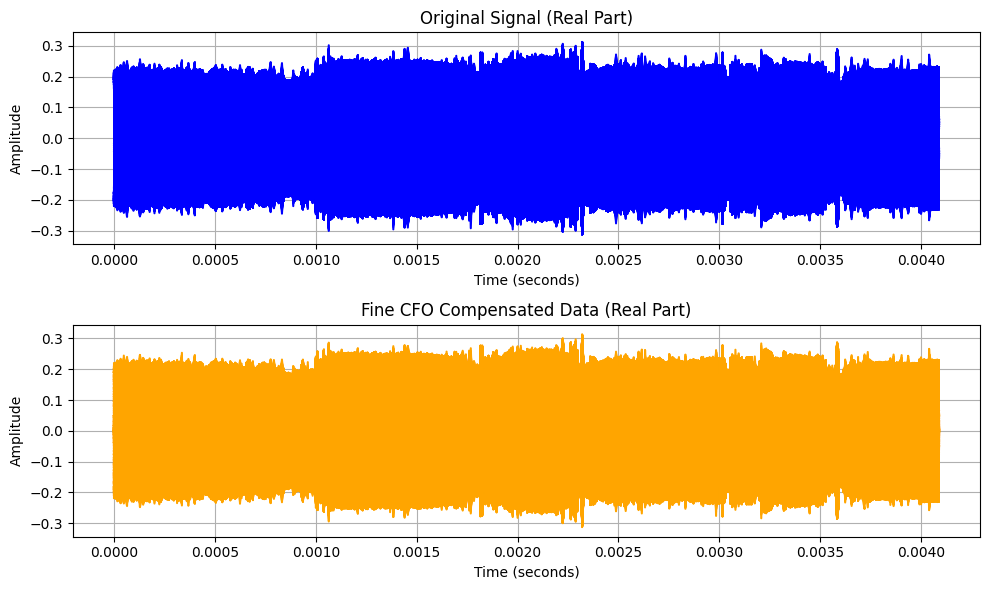

In [18]:


# Step 3: Plot the real (original) data and compensated data
# Extract real parts for visualization purposes
real_original_data = np.real(synchronized_data[:512])

real_compensated_data = np.real(compensated_data2[:512])


# Create a time axis for plotting (optional, based on the length of your data)
#time = np.arange(data.shape[0]) * Ts
#time = 512 * Ts
time = np.arange(512) * Ts
# Plotting
plt.figure(figsize=(10, 6))

# Plot original signal
plt.subplot(2, 1, 1)
plt.plot(time, real_original_data, label="Original Data", color='blue')
plt.title("Original Signal (Real Part)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot compensated signal
plt.subplot(2, 1, 2)
plt.plot(time, real_compensated_data, label="Fine CFO Compensated Data", color='orange')
plt.title("Fine CFO Compensated Data (Real Part)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()




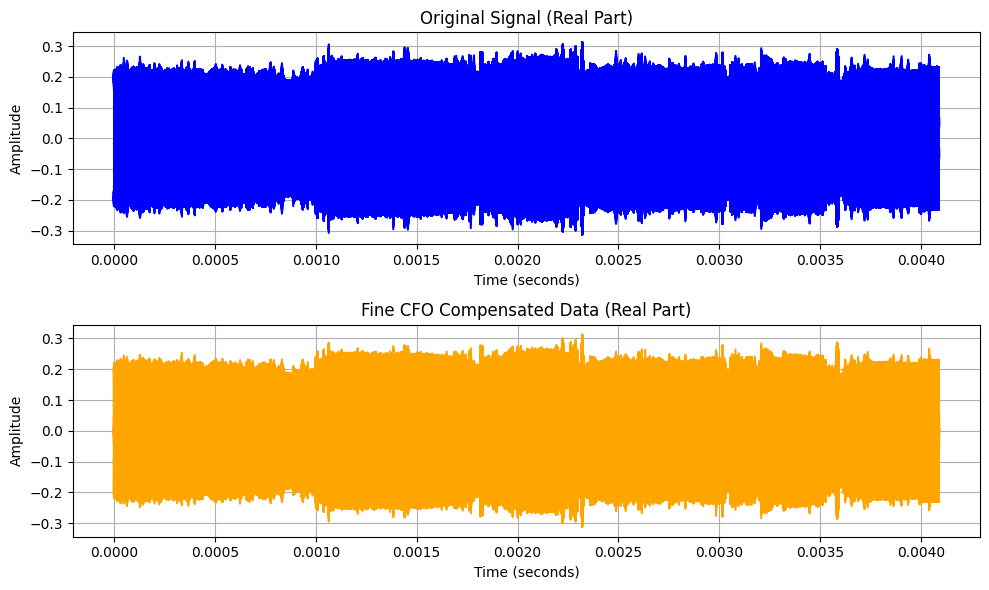

In [19]:


# Step 3: Plot the real (original) data and compensated data
# Extract real parts for visualization purposes
real_original_data = np.real(augmented_sample[:512])

real_compensated_data = np.real(compensated_data2[:512])


# Create a time axis for plotting (optional, based on the length of your data)
#time = np.arange(data.shape[0]) * Ts
#time = 512 * Ts
time = np.arange(512) * Ts
# Plotting
plt.figure(figsize=(10, 6))

# Plot original signal
plt.subplot(2, 1, 1)
plt.plot(time, real_original_data, label="Original Data", color='blue')
plt.title("Original Signal (Real Part)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot compensated signal
plt.subplot(2, 1, 2)
plt.plot(time, real_compensated_data, label="Fine CFO Compensated Data", color='orange')
plt.title("Fine CFO Compensated Data (Real Part)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()




In [20]:
data=compensated_data2

In [21]:
def normalize_data(data):
    rms = np.sqrt(np.mean(np.abs(data)**2))
    return data / rms
normalized_data = normalize_data(data)

In [22]:
data=normalized_data

In [23]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(data)
imaginary_part = np.imag(data)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 1D CNN
data_real_values = data_normalized.reshape((data.shape[0],data.shape[1], 2))

# Now 'data_reshaped' can be used as input to your 1D CNN model


In [25]:
data_real_values.shape

(5000, 4350, 2)

In [85]:
np.unique(label)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [24]:
input_data=data_real_values

In [25]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [26]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

In [27]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = label  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)






In [28]:


# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)




In [29]:
# Apply STFT to get the spectrogram
_, _, Zxx = stft(data_scaled, nperseg=64)
data_spectrogram = np.abs(Zxx)




In [30]:


# Reshape data for LSTM input (samples, timesteps, features)
n_samples, n_timesteps, n_features = data_spectrogram.shape

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)


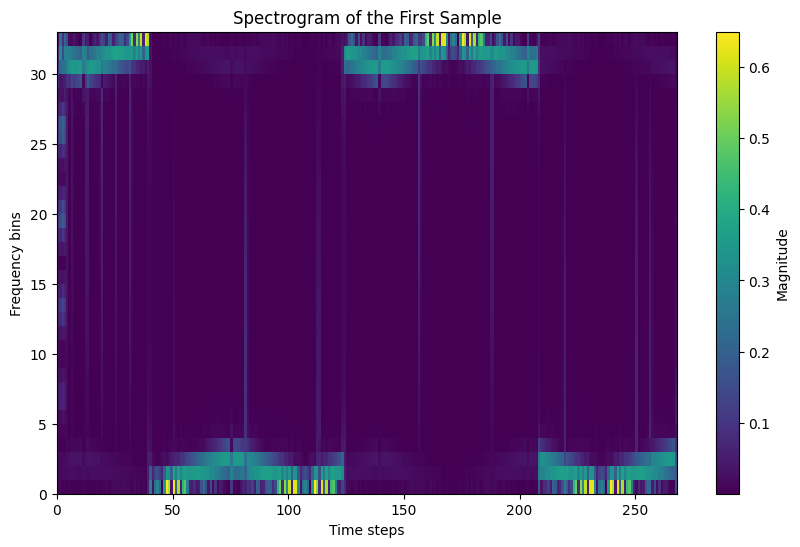

In [31]:
# Plot the spectrogram for the first sample in the training data
plt.figure(figsize=(10, 6))
plt.pcolormesh(np.abs(data_spectrogram[0]), cmap='viridis')
plt.title('Spectrogram of the First Sample')
plt.ylabel('Frequency bins')
plt.xlabel('Time steps')
plt.colorbar(label='Magnitude')
plt.show()

In [49]:
data_spectrogram.shape

(5000, 33, 302)

In [32]:


# Reshape data for LSTM input (samples, timesteps, features)
n_samples, n_timesteps, n_features = data_spectrogram.shape

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)


/usr/local/python/3.10.13/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300


2024-12-14 16:52:06.644375: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 113203200 exceeds 10% of free system memory.


100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.1571 - loss: 2.4892 - val_accuracy: 0.2087 - val_loss: 2.2129
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3302 - loss: 1.5499 - val_accuracy: 0.2488 - val_loss: 1.9502
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4289 - loss: 1.2052 - val_accuracy: 0.3800 - val_loss: 1.7241
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4627 - loss: 1.1115 - val_accuracy: 0.3825 - val_loss: 1.1797
Epoch 5/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5458 - loss: 0.9621 - val_accuracy: 0.3950 - val_loss: 1.3569
Epoch 6/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5326 - loss: 0.9230 - val_accuracy: 0.3100 - val_loss: 1.4741
Epoch 7/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4881 - loss: 0.9847 - val_accuracy: 0.2862 - val_loss: 1.8922
Epoch 8/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5596 - loss: 0.8856 - val_accuracy

2024-12-14 17:09:24.085412: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 141504000 exceeds 10% of free system memory.


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


Accuracy: 96.00%
Precision: 96.08%
Recall: 96.00%
F1 Score: 96.01%


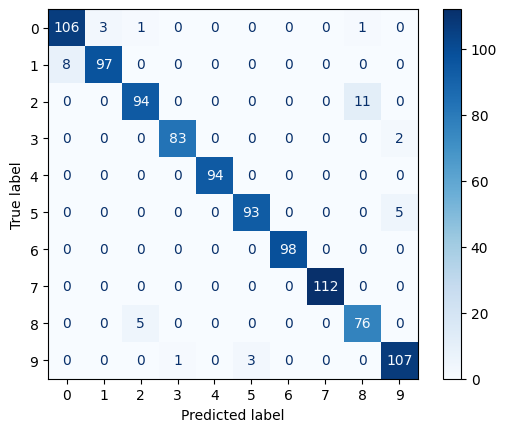

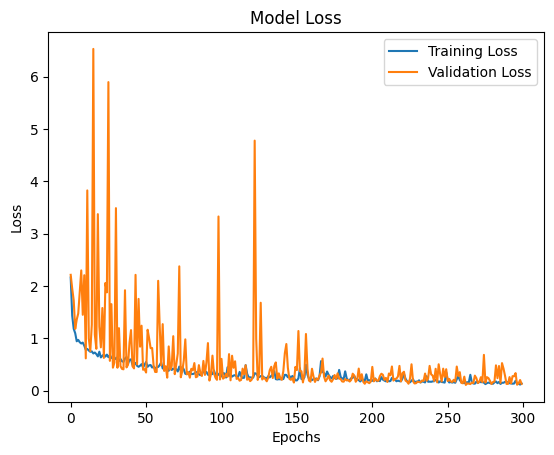

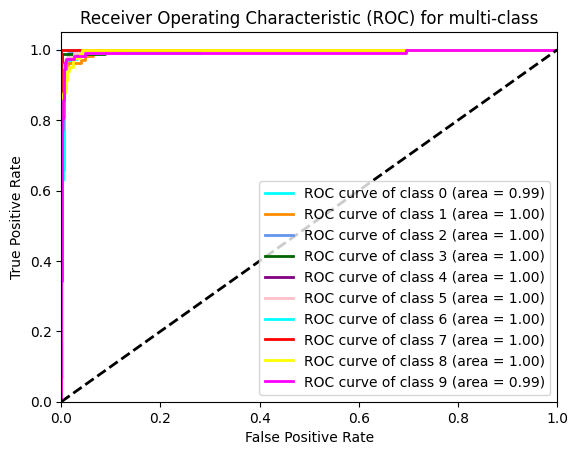

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 0.99


In [33]:
from keras.layers import BatchNormalization


# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))

model.add(Dense(10, activation='softmax'))  # Assuming binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=300, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('700_bilstm1_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=10, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'A700_xgboost70_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

Accuracy: 96.00%
Precision: 96.11%
Recall: 96.00%
F1 Score: 96.01%


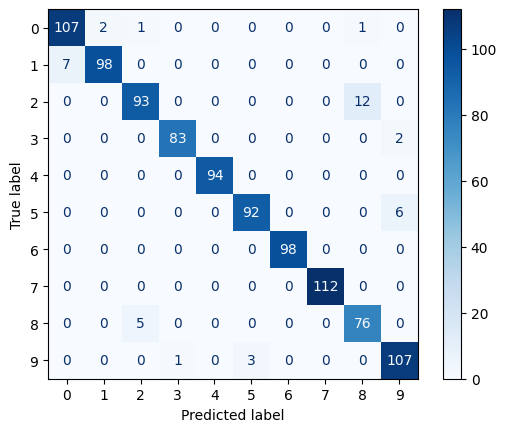

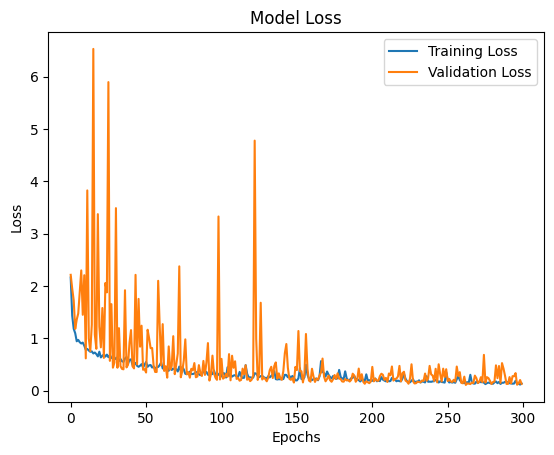

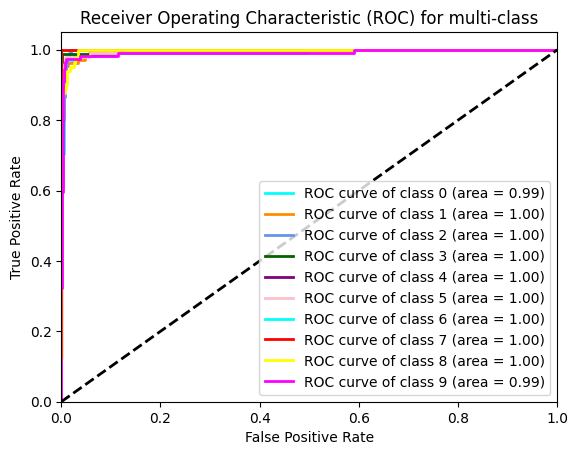

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 0.99


In [37]:
### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'B90_xgboost9_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

/usr/local/python/3.10.13/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/350


2024-12-14 17:40:11.106093: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 113203200 exceeds 10% of free system memory.


100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.1801 - loss: 2.3727 - val_accuracy: 0.0725 - val_loss: 2.1891
Epoch 2/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3934 - loss: 1.4180 - val_accuracy: 0.3675 - val_loss: 1.2928
Epoch 3/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4377 - loss: 1.1925 - val_accuracy: 0.3487 - val_loss: 1.5175
Epoch 4/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4704 - loss: 1.0602 - val_accuracy: 0.1937 - val_loss: 2.5026
Epoch 5/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5086 - loss: 1.0005 - val_accuracy: 0.3025 - val_loss: 1.4372
Epoch 6/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5111 - loss: 0.9857 - val_accuracy: 0.5850 - val_loss: 0.8340
Epoch 7/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5284 - loss: 0.9355 - val_accuracy: 0.3837 - val_loss: 1.4926
Epoch 8/350
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5642 - loss: 0.8601 - val_accuracy

2024-12-14 17:59:58.351179: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 141504000 exceeds 10% of free system memory.


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


Accuracy: 95.90%
Precision: 95.93%
Recall: 95.90%
F1 Score: 95.90%


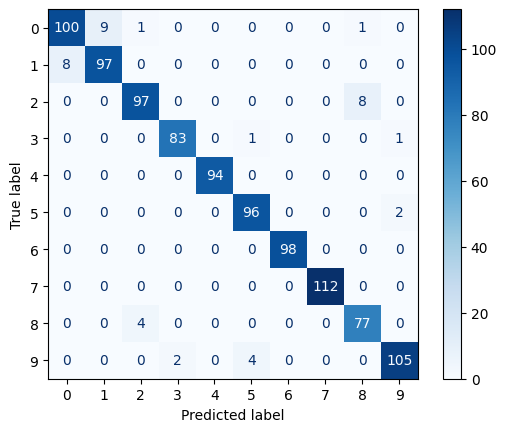

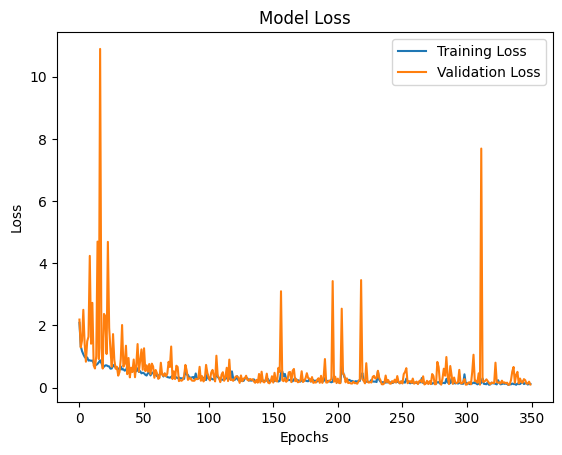

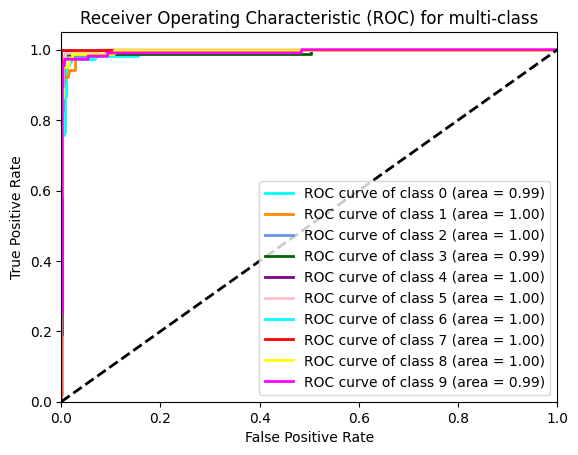

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 0.99
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 0.99


In [38]:
from keras.layers import BatchNormalization


# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))

model.add(Dense(10, activation='softmax'))  # Assuming binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=350, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('Y_bilstm13_feature_extractor.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=10, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'Y2_xgboost13_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

Accuracy: 96.20%
Precision: 96.21%
Recall: 96.20%
F1 Score: 96.20%


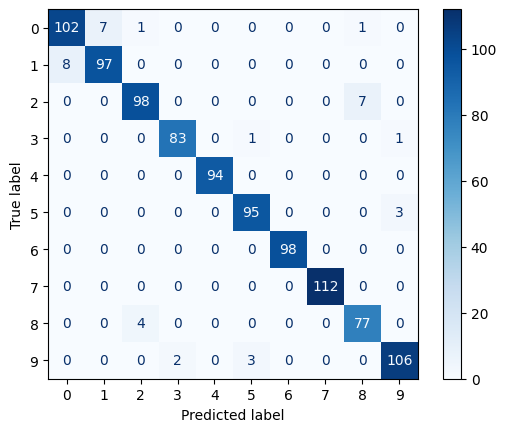

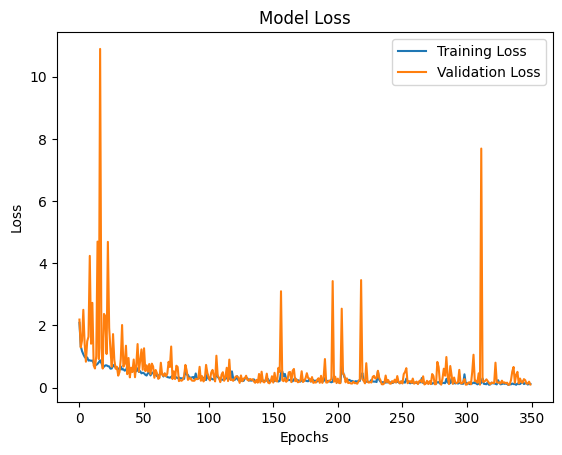

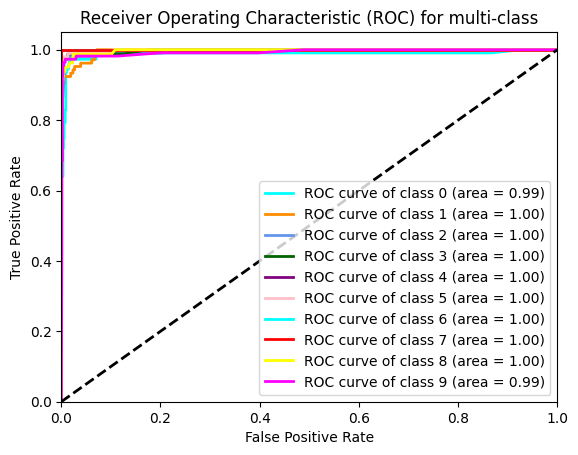

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 0.99


In [43]:
### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=500, learning_rate=0.005, max_depth=10, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'T42_xgboost4_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

Accuracy: 96.10%
Precision: 96.11%
Recall: 96.10%
F1 Score: 96.10%


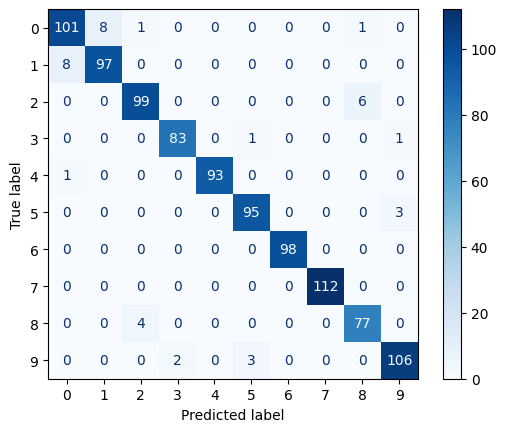

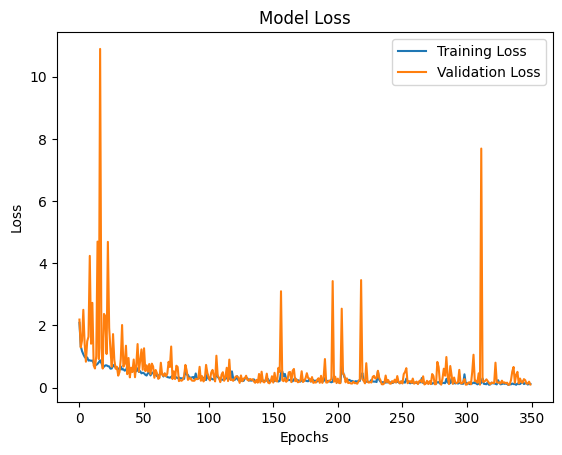

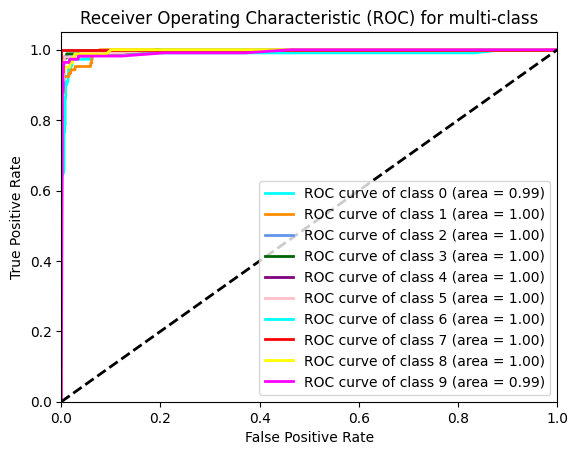

Class 0 AUC: 0.99
Class 1 AUC: 1.00
Class 2 AUC: 1.00
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 0.99


In [63]:
### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=300, learning_rate=0.005, max_depth=10, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'R233_xgboost23_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
# Plot the loss function
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for multi-class ROC
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")

/home/codespace/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 95.90%
Precision: 95.93%
Recall: 95.90%
F1 Score: 95.90%


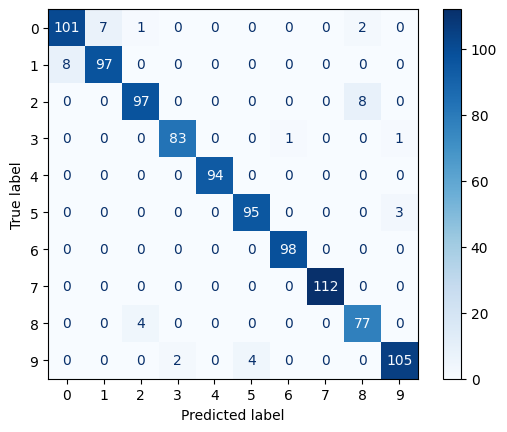

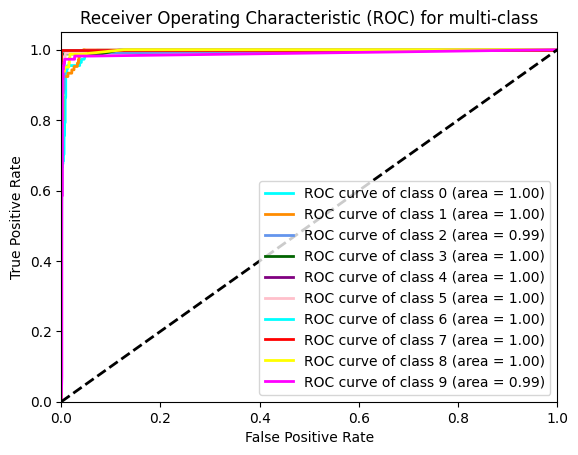

Class 0 AUC: 1.00
Class 1 AUC: 1.00
Class 2 AUC: 0.99
Class 3 AUC: 1.00
Class 4 AUC: 1.00
Class 5 AUC: 1.00
Class 6 AUC: 1.00
Class 7 AUC: 1.00
Class 8 AUC: 1.00
Class 9 AUC: 0.99


In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import joblib

# Train the RandomForest classifier on the extracted features
clf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, bootstrap=True, oob_score=True)
clf.fit(features_train, label_train)

# Save the RandomForest model
joblib.dump(clf, 'Y1_randomforest1_model.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# ROC and AUC calculations for RandomForest
label_binarized = label_binarize(label_test, classes=[i for i in range(10)])  # Assuming 10 classes
n_classes = label_binarized.shape[1]

# Get the predicted probabilities for each class
y_score = clf.predict_proba(features_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'purple', 'pink', 'cyan', 'red', 'yellow', 'magenta'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for multi-class')
plt.legend(loc="lower right")
plt.show()

# Print AUC for each class
for i in range(n_classes):
    print(f"Class {i} AUC: {roc_auc[i]:.2f}")
